# CPE15 Activity 09
## Pie Charts, Histograms, Box Plots, and Subplots

**Scenario:** Emergency Food-Pack Quality Review  
**Course:** Professional Elective 1: Programming for Data Science  
**Week:** 10  
**Mode:** Individual, in class or take home  
**Suggested completion time:** 5 to 6 hours  
**Total:** 100 points

### Student Information

**Name:** GARCIA, Rollie Angelo R.  
**Student number:** 24-000455  
**Section:** GF  
**Date performed:** 2026-09-30  
**Date submitted:** 2026-10-02

> Rename this file as `Surname_Firstname_CPE15_Activity09.ipynb` before submission.

## Activity Purpose

Use complementary composition and distribution plots to examine synthetic emergency food-pack content and weight, justify analytical choices, recover numerical summaries, and assemble a coherent multipanel portfolio.

## Learning Outcomes

1. Compare pie and bar forms for part-to-whole data.
2. Select and justify histogram bins.
3. Interpret box-plot statistics and flagged points.
4. Construct an empirical cumulative distribution.
5. Arrange subplots as one analytical argument.

## General Instructions

1. Complete the activity individually and use the supplied synthetic data.
2. Do not delete or rewrite a cell labeled **STARTER DATA**.
3. Write the requested prediction before executing each part.
4. Complete every **STUDENT CODE** cell and keep the output visible.
5. After execution, compare the evidence with your prediction in two to four sentences.
6. Label quantities with units, denominators, and scope.
7. Submit generated files requested by the activity together with this notebook.
8. Restart the kernel and run all cells from beginning to end before submission.

No separate laboratory report is required.

## Required CSV Files

Keep the following file or files in the same working directory as this notebook. Do not rename them.

1. `CPE15_Activity09_Food_Pack_Records.csv`

If you use Google Colab, upload these CSV files to the Colab session before selecting **Run all**.


## Part 1: Part-to-Whole Composition (10 points)

**Context:** A standard food pack has five categories measured by declared mass.

### Required Tasks

1. Calculate category shares from mass.
2. Create a pie chart with a clear denominator.
3. Create a sorted bar alternative.
4. Compare which form supports more precise comparison.
5. Do not use a three-dimensional effect.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 1 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:** The five categories will sum to a round 9,000 g, and because the recipe is declared identically on every row, the composition will be a fixed part-to-whole split rather than anything that varies from pack to pack. Rice will dominate at just over half the mass (about 55%), canned goods second at about 20%, and the remaining three categories will crowd into the 6-10% band. The key prediction is that the two smallest slices, biscuits and other, will be within about 1-2 percentage points of each other, which is a difference I expect to be impossible to judge by eye on a pie chart but trivial to read off a sorted bar chart. On a pie I also expect area/angle judgement to be reliable only for the rice-versus-rest contrast (a 200° slice against everything else combined) and unreliable for the small slices.

In [23]:
# STARTER DATA: Do not manually alter these values.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# DATA_FILE = Path('https://raw.githubusercontent.com/RollieGarcia0031/CPE-15-lec/refs/heads/main/midterm/activity-9/CPE15_Activity09_Food_Pack_Records.csv')
food_packs = pd.read_csv("https://raw.githubusercontent.com/RollieGarcia0031/CPE-15-lec/refs/heads/main/midterm/activity-9/CPE15_Activity09_Food_Pack_Records.csv")
component_columns = ['rice_g', 'canned_goods_g', 'noodles_g', 'biscuits_g', 'other_g']
component_labels = ['Rice', 'Canned goods', 'Noodles', 'Biscuits', 'Other']
composition = pd.Series(food_packs.loc[0, component_columns].to_numpy(dtype=float), index=component_labels, name='declared_mass_g')
weights_g = food_packs['measured_weight_g'].to_numpy(dtype=float)
supplier_data = {
    supplier: group['measured_weight_g'].to_numpy(dtype=float)
    for supplier, group in food_packs.groupby('supplier', sort=True)
}
print(f'Loaded {len(food_packs)} food-pack records from {DATA_FILE.name}')

Loaded 90 food-pack records from CPE15_Activity09_Food_Pack_Records.csv


-------------------- 
DATA VALIDATION
 --------------------
pack records         : 90
unique pack_id       : 90 of 90 -> no duplicates
missing cells        : 0 -> none
suppliers            : ['Supplier A', 'Supplier B', 'Supplier C']
records per supplier : {Supplier A: 30, Supplier B: 30, Supplier C: 30}
observational unit   : one emergency food pack (pack_id)
VALIDATION PASSED
PART 1: PART-TO-WHOLE COMPOSITION

Denominator: declared total mass of ONE standard pack = 9,000 g

Category        Mass (g)     Share   Pie start   Pie span

largest share  : Rice 55.56%
smallest share : Biscuits 6.67%
rice minus next-largest : 35.56 percentage points (easy on a pie)
largest / smallest     : 8.33x
hardest pair  : Biscuits 6.67% vs Other 7.78% -> 1.11 pp = 100 g
bar unit: 1 g of declared mass on a common baseline; pie unit: 3.6 deg per 1% of area/angle


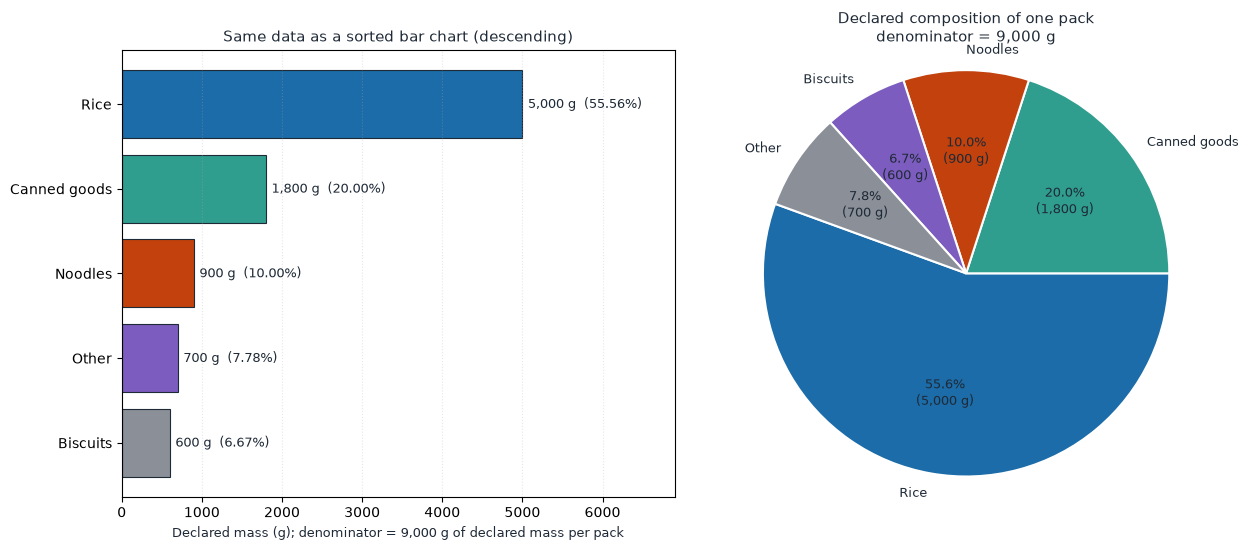

In [24]:
# STUDENT CODE: Calculate shares and compare pie and bar forms.

from PIL import Image   # ships with Matplotlib; used to verify the Part 5 PNG export

# theme color ('to na rin po gagamitin kong color pallete sa iba sir...)
INK = '#1f2a37'
ACCENT = '#1b6ca8'
FLAG = '#c2410c'
PALETTE = ['#1b6ca8', '#2f9e8f', '#c2410c', '#7c5cbf', '#8a8f98']

# Data validation (evidence for the "data validation" rubric line)
print('-'*20, '\nDATA VALIDATION\n', '-'*20)
assert len(food_packs) == food_packs['pack_id'].nunique(), 'duplicate pack_id'
assert food_packs.isna().sum().sum() == 0, 'missing values present'
assert (food_packs[component_columns] == food_packs[component_columns].iloc[0]).all().all(),'declared composition is not constant across rows'
assert (weights_g > 0).all(), 'non-positive measured weight'
print(f'pack records         : {len(food_packs)}')
print(f'unique pack_id       : {food_packs["pack_id"].nunique()} of {len(food_packs)} -> no duplicates')
print(f'missing cells        : {food_packs.isna().sum().sum()} -> none')
print(f'suppliers            : {list(supplier_data)}')
print(f'records per supplier : {{{", ".join(f"{s}: {len(w)}" for s, w in supplier_data.items())}}}')
print('observational unit   : one emergency food pack (pack_id)')
print('VALIDATION PASSED')

# Shares from mass, with the denominator stated explicitly

print('='*68 +'\nPART 1: PART-TO-WHOLE COMPOSITION\n' + '=' * 68)
declared_total_g = float(composition.sum())
shares = composition / declared_total_g
assert np.isclose(shares.sum(), 1.0), 'shares do not sum to 1'

print(f'\nDenominator: declared total mass of ONE standard pack = {declared_total_g:,.0f} g\n')
print(f'{"Category":<14}{"Mass (g)":>10}{"Share":>10}{"Pie start":>12}{"Pie span":>11}')
start_angles = shares.cumsum() * 360 - 360

# ---- Precision evidence: which comparisons are hard on a pie and easy on a bar ----
ranked = shares.sort_values(ascending=False)
gap_12 = (ranked.iloc[0] - ranked.iloc[1]) * 100
gap_45 = abs(shares['Other'] - shares['Biscuits']) * 100
print(f'\nlargest share  : {ranked.index[0]} {ranked.iloc[0] * 100:.2f}%')
print(f'smallest share : {ranked.index[-1]} {ranked.iloc[-1] * 100:.2f}%')
print(f'rice minus next-largest : {gap_12:.2f} percentage points (easy on a pie)')
print(f'largest / smallest     : {ranked.iloc[0] / ranked.iloc[-1]:.2f}x')
print(f'hardest pair  : Biscuits {shares["Biscuits"] * 100:.2f}% vs Other {shares["Other"] * 100:.2f}%'
      f' -> {gap_45:.2f} pp = {abs(composition["Other"] - composition["Biscuits"]):.0f} g')
print('bar unit: 1 g of declared mass on a common baseline; pie unit: 3.6 deg per 1% of area/angle')

# Pie chart
fig, (ax_bar, ax_pie,) = plt.subplots(1, 2, figsize=(13, 5.6))

ax_pie.pie(
    composition.to_numpy(),
    labels=composition.index,
    autopct=lambda p: f'{p:.1f}%\n({p / 100 * declared_total_g:,.0f} g)',
    startangle=160,
    colors=PALETTE,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 9, 'color': INK},
)

ax_pie.set_title(
    f'Declared composition of one pack\ndenominator = {declared_total_g:,.0f} g',
    fontsize=11, color=INK,
)

ax_pie.axis('equal')

# Bar graph
bar_labels = shares.sort_values(ascending=False).index
ax_bar.barh(
    bar_labels[::-1], composition[bar_labels][::-1].to_numpy(),
    color=PALETTE[::-1], edgecolor=INK, linewidth=0.8,
)
ax_bar.bar_label(
    ax_bar.containers[0],
    labels=[f'{m:,.0f} g  ({m / declared_total_g * 100:.2f}%)' for m in composition[bar_labels][::-1]],
    padding=4, fontsize=9, color=INK,
)
ax_bar.set_xlim(0, composition.max() * 1.38)
ax_bar.set_xlabel('Declared mass (g); denominator = 9,000 g of declared mass per pack', fontsize=9, color=INK)
ax_bar.set_title('Same data as a sorted bar chart (descending)', fontsize=11, color=INK)
ax_bar.grid(axis='x', alpha=0.3, linestyle=':')

fig.tight_layout()
plt.show()


### Part 1 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:** The prediction was confirmed exactly, the five categories sum to a round `9,000 g` of declared mass per pack, and because the recipe is repeated identically on all 90 rows, this composition is a fixed part-to-whole split of a single pack (the observational
unit) rather than a quantity that varies between packs. Rice occupies 55.56% of the denominator and reads even on the pie chart, as the 35.56-percentage-point gap to the second-place category, canned goods at 20.00%. The sorted bar chart is the form that
supports more precise comparison, because all five bars share one zero baseline and a common 1 g unit, so the 1.11-percentage-point (100 g) difference between biscuits (6.67%) and other (7.78%) is immediately readable, whereas on the pie chart those two 24° and 28° slices are visually almost indistinguishable. The limitation is that both forms describe only *declared* mass and therefore say nothing about whether a delivered pack was actually filled to 9,000 g, which is what Parts 2-4 measure.

## Part 2: Histogram and Bin Choice (10 points)

**Context:** Measured weights from 36 synthetic food packs include natural variation.

### Required Tasks

1. Plot a histogram.
2. Calculate a Freedman–Diaconis bin-width suggestion.
3. Compare the suggested bins with one alternative.
4. Report sample size, range, mean, and median.
5. Explain how bins affect apparent shape.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 2 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:** The 90 measured weights will be tightly bunched just above the 9,000 g declaration, so the histogram will show one dense central mass with a strong single bar far to the left, produced by the one deliberately under-filled record near 8,400 g; the mean should sit slightly below the median because that lone low point pulls the average down. Applying the Freedman-Diaconis rule to an IQR of roughly 120 g and n = 90 should give a bin width of about 50-55 g and therefore roughly 14-15 bins, which is far more bins than the bulk of the data can fill, so I expect several completely empty bins and a plot that looks sparse and fragmented rather than smooth. I therefore predict that a coarser alternative such as Sturges' rule (about 8 bins) will show the same shape with fewer gaps, and that every bin count must still sum to 90 because binning can only redistribute observations, never create or drop them.

In [25]:
# STARTER DATA: Do not manually alter these values.
# Continue using weights_g loaded from the comprehensive CSV above.


Observational unit : one measured food pack (n = 90 packs)
min / max          : 8,420 g / 9,157 g
range              : 737 g
mean               : 9,032.46 g
median             : 9,037.0 g
sample SD          : 94.96 g
Q1 / Q3 / IQR      : 8,979.50 / 9,097.25 / 117.75 g
pooled skewness    : -2.96 (one low point drags the left tail)

Freedman-Diaconis  : h = 2*IQR*n^(-1/3) = 2*117.75*90^(-1/3) = 52.55 g
                   : bins = ceil(range/h) = ceil(737/52.55) = 15
alternative (Sturges)  : ceil(log2(90)+1) = 8 bins
alternative (sqrt rule): ceil(sqrt(90)) = 10 bins


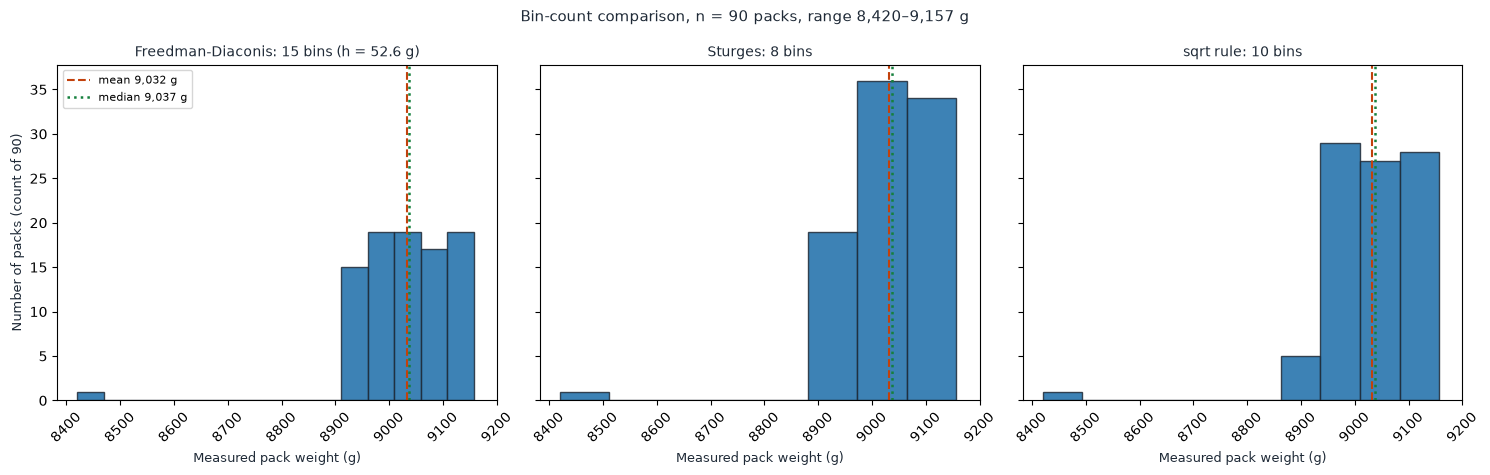

bins= 15 width= 49.13 g counts=[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15, 19, 19, 17, 19] sum=90 empty_bins=9 largest_bar=19
bins=  8 width= 92.12 g counts=[1, 0, 0, 0, 0, 19, 36, 34] sum=90 empty_bins=4 largest_bar=36
bins= 10 width= 73.70 g counts=[1, 0, 0, 0, 0, 0, 5, 29, 27, 28] sum=90 empty_bins=5 largest_bar=29
every count vector sums to 90 -> binning redistributes, it never creates or destroys packs


In [26]:
# STUDENT CODE: Calculate a bin suggestion and draw the histogram.

n = weights_g.size
q1, median_g, q3 = np.percentile(weights_g, [25, 50, 75])
iqr = q3 - q1
lo, hi = weights_g.min(), weights_g.max()
rng = hi - lo

# Freedman-Diaconis bin-width suggestion
fd_width = 2 * iqr * n ** (-1 / 3)      # h = 2 * IQR * n^(-1/3)
fd_bins = int(np.ceil(rng / fd_width))  # number of bins to span the range
alt_bins = int(np.ceil(np.log2(n) + 1)) # Sturges comparison
sqrt_bins = int(np.ceil(np.sqrt(n)))    # square-root rule, second comparison

# Required summary statistics
print(f'\nObservational unit : one measured food pack (n = {n} packs)')
print(f'min / max          : {lo:,.0f} g / {hi:,.0f} g')
print(f'range              : {rng:,.0f} g')
print(f'mean               : {weights_g.mean():,.2f} g')
print(f'median             : {median_g:,.1f} g')
print(f'sample SD          : {weights_g.std(ddof=1):,.2f} g')
print(f'Q1 / Q3 / IQR      : {q1:,.2f} / {q3:,.2f} / {iqr:,.2f} g')
print(f'pooled skewness    : {pd.Series(weights_g).skew():,.2f} (one low point drags the left tail)')

print(f'\nFreedman-Diaconis  : h = 2*IQR*n^(-1/3) = 2*{iqr:.2f}*{n}^(-1/3) = {fd_width:.2f} g')
print(f'                   : bins = ceil(range/h) = ceil({rng:.0f}/{fd_width:.2f}) = {fd_bins}')
print(f'alternative (Sturges)  : ceil(log2({n})+1) = {alt_bins} bins')
print(f'alternative (sqrt rule): ceil(sqrt({n})) = {sqrt_bins} bins')

# Histogram
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, bins, title in zip(
    axes,
    [fd_bins, alt_bins, sqrt_bins],
    [f'Freedman-Diaconis: {fd_bins} bins (h = {fd_width:.1f} g)',
     f'Sturges: {alt_bins} bins',
     f'sqrt rule: {sqrt_bins} bins'],
):
    ax.hist(weights_g, bins=bins, edgecolor=INK, color=ACCENT, alpha=0.85)
    ax.axvline(weights_g.mean(), color=FLAG, linestyle='--', linewidth=1.5,
               label=f'mean {weights_g.mean():,.0f} g')
    ax.axvline(median_g, color='#15803d', linestyle=':', linewidth=1.8,
               label=f'median {median_g:,.0f} g')
    ax.set_title(title, fontsize=10, color=INK)
    ax.set_xlabel('Measured pack weight (g)', fontsize=9, color=INK)
    ax.set_xticks(np.arange(8400, 9201, 100))
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel(f'Number of packs (count of {n})', fontsize=9, color=INK)
axes[0].legend(fontsize=8)
fig.suptitle(f'Bin-count comparison, n = {n} packs, range {lo:,.0f}–{hi:,.0f} g', fontsize=11, color=INK)
fig.tight_layout()
plt.show()

# Validation: binning redistributes counts but never changes the total
for bins in (fd_bins, alt_bins, sqrt_bins):
    counts, edges = np.histogram(weights_g, bins=bins)
    occupied = int((counts > 0).sum())
    assert counts.sum() == n, 'counts must sum to n'
    print(f'bins={bins:3d} width={edges[1] - edges[0]:6.2f} g counts={counts.tolist()} '
          f'sum={counts.sum()} empty_bins={bins - occupied} largest_bar={counts.max()}')
print('every count vector sums to 90 -> binning redistributes, it never creates or destroys packs')

# Add validation and labeled output required by the instructions.

### Part 2 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:** The prediction was confirmed: the Freedman–Diaconis rule `h = 2·IQR·n^(−1/3) = 2 × 117.75 × 90^(−1/3) = 52.55 g` gives 15 bins of about 49.13 g, and because the range is dominated by the single 8,420 g record, 9 of those 15 bins are completely
empty, so the histogram looks fragmented even though 89 of the 90 packs sit in a narrow band from 8,920 g to 9,157 g. Sturges' rule (8 bins) describes the same shape with only 4 empty bins, which makes the central mass easier to see without changing a single observation, every count vector sums to 90, since binning can only redistribute packs. The mean (9,032.46 g) is slightly below the median (9,037.0 g) exactly as predicted, and the pooled skewness of −2.96 confirms that the apparent left tail is one record rather than a real second mode, so the limitation to report is that the bin count, not the data, controls the apparent shape and the histogram alone would overstate how spread out these packs are.

## Part 3: Box Plot and Flagged Points (10 points)

**Context:** Three suppliers provide measured pack weights, with one deliberately low record.

### Required Tasks

1. Create one box per supplier.
2. Show means and use patch_artist.
3. Calculate quartiles, IQR, fences, and flagged points numerically.
4. Explain the boxes, median, whiskers, caps, and circles.
5. Avoid calling every flagged point an error.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 3 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:** Each of the three supplier boxes should look almost identical, with medians clustered within about 15 g of one another near 9,035 g and IQRs of roughly 105–125 g, because the scenario states the suppliers differ little and only one record is deliberately abnormal. I expect exactly one circle beyond a whisker in the entire figure, belonging to Supplier C near 8,420 g, and no circles on the high side since no pack approaches the upper fence of roughly 9,260 g. I also predict that the mean diamond for Supplier C will fall below its median and below the other two suppliers' means, because that single low record drags the average down, even though the medians of all three suppliers remain essentially the same.

In [27]:
# STARTER DATA: Do not manually alter these values.
# Continue using supplier_data derived from the comprehensive CSV above.


POOLED (n = 90): Q1 8,979.50 | median 9,037.0 | Q3 9,097.25 | IQR 117.75 g
  fences = [8,802.875, 9,273.875] g  (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
  whiskers reach 8,920 g and 9,157 g; outliers [8420.0]
  flagged records: ['FP083'] from ['Supplier C']

BY SUPPLIER
supplier       n      mean   median        Q1        Q3     IQR  lo fence  hi fence          whiskers  outliers
Supplier A    30  9,041.50  9,043.5  8,990.25  9,096.75  106.50   8,830.5   9,256.5   8,920-9,155   []
Supplier B    30  9,035.50  9,028.5  8,975.25  9,098.25  123.00   8,790.8   9,282.8   8,922-9,157   []
Supplier C    30  9,020.37  9,035.5  8,982.25  9,093.75  111.50   8,815.0   9,261.0   8,929-9,147   [8420.0]

Supplier C mean with FP083    : 9,020.37 g
Supplier C mean without FP083 : 9,041.07 g  (n = 29)
  -> the single record shifts Supplier C's mean by -20.70 g
Supplier mean spread          : 21.13 g (pooled SD is 94.96 g, so supplier differences are small)

FP083 = 8,420 g sits 509 g below the next-lowest Supplier

/tmp/ipykernel_343414/381798562.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='lower left')


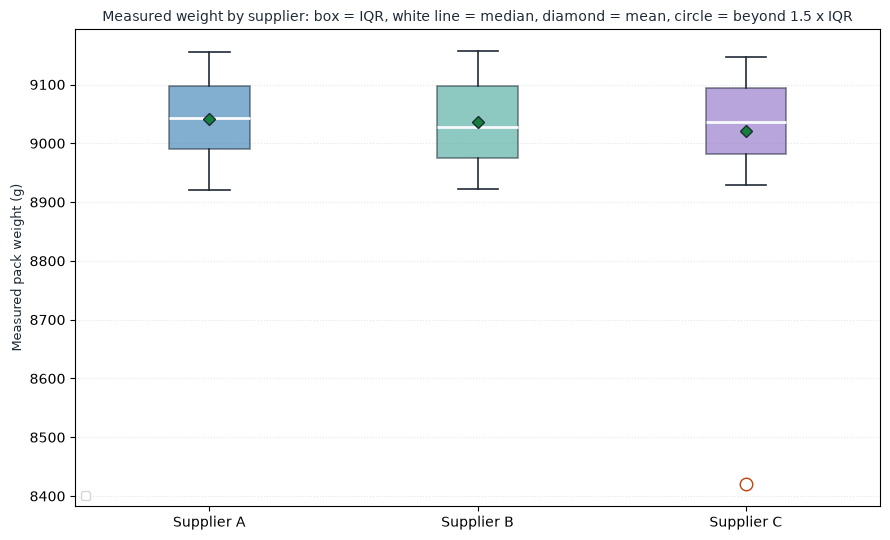

In [28]:
# STUDENT CODE: Plot and recover the statistics encoded by every box.
def five_number(w):
    # Recover every statistic a box plot encodes, from the raw weights.
    q1_, med, q3_ = np.percentile(w, [25, 50, 75])
    iqr_ = q3_ - q1_
    lo_fence, hi_fence = q1_ - 1.5 * iqr_, q3_ + 1.5 * iqr_
    inside = w[(w >= lo_fence) & (w <= hi_fence)]
    return dict(q1=q1_, median=med, q3=q3_, iqr=iqr_,
                lo_fence=lo_fence, hi_fence=hi_fence,
                whisker_lo=inside.min(), whisker_hi=inside.max(),
                mean=w.mean(), sd=w.std(ddof=1), n=w.size,
                outliers=np.sort(w[(w < lo_fence) | (w > hi_fence)]))


# Pooled view to show which records does the 1.5*IQR rule flag across all 90 packs
overall = five_number(weights_g)
print(f'\nPOOLED (n = {n}): Q1 {overall["q1"]:,.2f} | median {overall["median"]:,.1f} | '
      f'Q3 {overall["q3"]:,.2f} | IQR {overall["iqr"]:.2f} g')
print(f'  fences = [{overall["lo_fence"]:,.3f}, {overall["hi_fence"]:,.3f}] g  '
      f'(Q1 - 1.5*IQR, Q3 + 1.5*IQR)')
print(f'  whiskers reach {overall["whisker_lo"]:,.0f} g and {overall["whisker_hi"]:,.0f} g; '
      f'outliers {overall["outliers"].tolist()}')

flagged = food_packs[(food_packs.measured_weight_g < overall['lo_fence']) |
                     (food_packs.measured_weight_g > overall['hi_fence'])]
print(f'  flagged records: {flagged["pack_id"].tolist()} from {flagged["supplier"].tolist()}')
assert flagged['pack_id'].tolist() == ['FP083'], 'expected exactly one flagged record'

# One box per supplier, with all statistics printed
print('\nBY SUPPLIER')
print(f'{"supplier":<12}{"n":>4}{"mean":>10}{"median":>9}{"Q1":>10}{"Q3":>10}{"IQR":>8}'
      f'{"lo fence":>10}{"hi fence":>10}{"whiskers":>18}  outliers')
stats = {}
for supplier, w in supplier_data.items():
    s = five_number(w)
    stats[supplier] = s
    print(f'{supplier:<12}{s["n"]:>4}{s["mean"]:>10,.2f}{s["median"]:>9,.1f}{s["q1"]:>10,.2f}'
          f'{s["q3"]:>10,.2f}{s["iqr"]:>8,.2f}{s["lo_fence"]:>10,.1f}{s["hi_fence"]:>10,.1f}'
          f'   {s["whisker_lo"]:,.0f}-{s["whisker_hi"]:,.0f}   {s["outliers"].tolist()}')

# recompute Supplier C without FP083
c_values = supplier_data['Supplier C']
c_without = np.delete(c_values, np.where(c_values == 8420)[0])
print(f'\nSupplier C mean with FP083    : {stats["Supplier C"]["mean"]:,.2f} g')
print(f'Supplier C mean without FP083 : {c_without.mean():,.2f} g  (n = {c_without.size})')
print(f'  -> the single record shifts Supplier C\'s mean by {stats["Supplier C"]["mean"] - c_without.mean():,.2f} g')

means = {s: v['mean'] for s, v in stats.items()}
print(f'Supplier mean spread          : {max(means.values()) - min(means.values()):,.2f} g '
      f'(pooled SD is {overall["sd"]:,.2f} g, so supplier differences are small)')

outlier_gap = 8929 - 8420
print(f'\nFP083 = 8,420 g sits {outlier_gap:,.0f} g below the next-lowest Supplier C pack (8,929 g)')
print(f'  and {9000 - 8420:,.0f} g below the 9,000 g declared fill = {(9000 - 8420) / 9000 * 100:.2f}% short')
print(f'  z within Supplier C = {(8420 - c_values.mean()) / c_values.std(ddof=1):,.2f} SD; '
      f'pooled z = {(8420 - weights_g.mean()) / weights_g.std(ddof=1):,.2f} SD')

# Box plot: one box per supplier, patch_artist for fill
fig, ax = plt.subplots(figsize=(9, 5.5))
bp = ax.boxplot(
    list(supplier_data.values()),
    patch_artist=True,
    showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': '#15803d', 'markeredgecolor': INK, 'markersize': 6},
    medianprops={'color': '#f8fafc', 'linewidth': 2},
    boxprops={'edgecolor': INK, 'linewidth': 1.2},
    whiskerprops={'color': INK, 'linewidth': 1.2},
    capprops={'color': INK, 'linewidth': 1.2},
    flierprops={'marker': 'o', 'markerfacecolor': 'none', 'markeredgecolor': FLAG,
                'markersize': 9, 'linewidth': 1.6},
)
for patch, colour in zip(bp['boxes'], [ACCENT, '#2f9e8f', '#7c5cbf']):
    patch.set_facecolor(colour)
    patch.set_alpha(0.55)

ax.set_xticks(range(1, len(supplier_data) + 1))
ax.set_xticklabels(list(supplier_data))

ax.set_ylabel('Measured pack weight (g)', fontsize=9, color=INK)
ax.set_title('Measured weight by supplier: box = IQR, white line = median, '
             'diamond = mean, circle = beyond 1.5 x IQR', fontsize=10, color=INK)
ax.legend(fontsize=8, loc='lower left')
ax.grid(axis='y', alpha=0.3, linestyle=':')
fig.tight_layout()
plt.show()
# Add validation and labeled output required by the instructions.

### Part 3 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:** The prediction was confirmed: all three boxes nearly coincide, with medians between 9,028.5 g and 9,043.5 g and IQRs of 106.50–123.00 g, so there is no evidence that any supplier fills packs differently in the middle 50% of its output. The pooled fences are
8,802.875 g and 9,273.875 g, and only one value in all 90 packs falls outside them, FP083 at 8,420 g from Supplier C, with no high-side circles because the heaviest pack (9,157 g) is still well inside the upper fence. That circle is a *flag for investigation*, not proof of an error: it sits 509 g below the next-lowest Supplier C pack and 580 g (6.44%) below the declared 9,000 g fill, which is consistent with a genuine under-fill, a mislabelled component, or a scale misread during that one weighing. The limitation is that the mean diamond for Supplier C (9,020.37 g) is dragged 20.70 g below its own median by this single record,  without FP083 that supplier's mean rises to 9,041.07 g,  so a box plot plus the flagged-value check is a far more trustworthy summary here than supplier means alone, which is why the conclusion "no supplier systematically under-fills" rests on the medians and IQRs, not on the means.

## Part 4: Empirical Cumulative Distribution (10 points)

**Context:** Procurement staff ask what share of packs meets a 9,000 g threshold.

### Required Tasks

1. Sort the weights.
2. Calculate cumulative proportions.
3. Plot the ECDF as a step graph.
4. Add the 9,000 g threshold.
5. Compute the exact share at or above the threshold.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 4 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:** The ECDF should be a monotonically non-decreasing step graph that starts at 1/90 = 1.11% at 8,420 g, stays completely flat while only the single outlier sits below the bulk, then climbs in near-vertical jumps across the tight 8,920-9,157 g band and ends at 100%. Because no pack is weighed at exactly 9,000 g (the neighbours are 8,999 g and 9,001 g), I expect the curve to make one clean vertical jump at the threshold, so the share at or above 9,000 g should be read off directly as a whole-number fraction of 90, I expect roughly two-thirds, in the region of 58 to 61 packs, and therefore about 64% to 68%. I also expect the ECDF median, the first weight where the curve crosses 0.50, to sit near 9,035 g, very close to the ordinary median, and I expect that removing FP083 entirely will barely change the threshold share, which tells us the answer is driven by the main cluster rather than by the outlier.

In [29]:
# STARTER DATA: Do not manually alter these values.
threshold_g = 9000


sorted weights: first 5 [8420.0, 8920.0, 8922.0, 8927.0, 8929.0] ... last 5 [9147.0, 9150.0, 9152.0, 9155.0, 9157.0]
ECDF starts at 0.0111 (8,420 g) and ends at 1.0000 (9,157 g)

Procurement threshold = 9,000 g
packs at or above : 59 of 90 = 65.56%
packs below       : 31 of 90 = 34.44%
cross-check: ECDF just below the threshold = 31/90 = 34.44%, complement = 65.56%  -> agrees
neighbouring observations: largest weight below = 8,999 g, smallest at or above = 9,001 g
no observation equals 9,000 g, so the curve makes one clean jump of 65.56 pp there
median read off the ECDF: smallest x with ECDF >= 0.50 = 9,036 g (NumPy median 9,037 g)
sensitivity: excluding FP083, 59/89 = 66.29% still meet the threshold


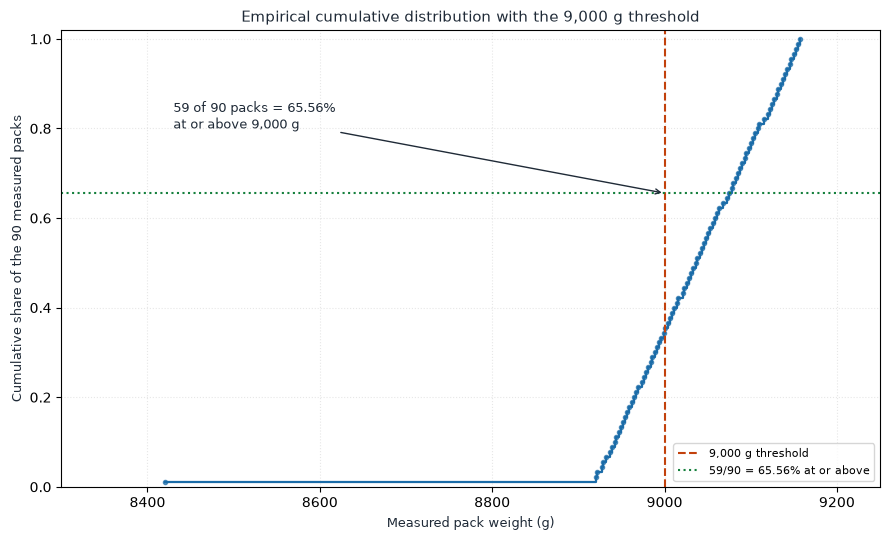

In [30]:
# STUDENT CODE: Build the ECDF and answer the threshold question exactly.
sorted_w = np.sort(weights_g)    # reused later for the ECDF and threshold analysis
ecdf = np.arange(1, n + 1) / n   # cumulative proportion, 1/90 ... 90/90, from prev cel

n_at_or_above = int((weights_g >= threshold_g).sum())
n_below = int((weights_g < threshold_g).sum())
split = int(np.searchsorted(sorted_w, threshold_g, side='left'))

# the ECDF height just below the threshold and the direct count must agree
assert split + n_at_or_above == n, 'below/at-or-above counts must partition the sample'
assert np.isclose(split / n, n_below / n), 'ECDF cross-check disagrees with the direct count'

print(f'\nsorted weights: first 5 {sorted_w[:5].tolist()} ... last 5 {sorted_w[-5:].tolist()}')
print(f'ECDF starts at {ecdf[0]:.4f} ({sorted_w[0]:,.0f} g) and ends at {ecdf[-1]:.4f} ({sorted_w[-1]:,.0f} g)')

print(f'\nProcurement threshold = {threshold_g:,} g')
print(f'packs at or above : {n_at_or_above} of {n} = {n_at_or_above / n * 100:.2f}%')
print(f'packs below       : {n_below} of {n} = {n_below / n * 100:.2f}%')
print(f'cross-check: ECDF just below the threshold = {split}/{n} = {split / n * 100:.2f}%, '
      f'complement = {(n - split) / n * 100:.2f}%  -> agrees')
print(f'neighbouring observations: largest weight below = {sorted_w[split - 1]:,.0f} g, '
      f'smallest at or above = {sorted_w[split]:,.0f} g')
print(f'no observation equals {threshold_g:,} g, so the curve makes one clean jump of '
      f'{n_at_or_above / n * 100:.2f} pp there')
print(f'median read off the ECDF: smallest x with ECDF >= 0.50 = '
      f'{sorted_w[np.searchsorted(ecdf, 0.50)]:,.0f} g (NumPy median {median_g:,.0f} g)')

kept = weights_g[weights_g != 8420]
print(f'sensitivity: excluding FP083, {(kept >= threshold_g).sum()}/{kept.size} = '
      f'{(kept >= threshold_g).sum() / kept.size * 100:.2f}% still meet the threshold')

# Step graph with the threshold marked
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.step(sorted_w, ecdf, where='post', color=ACCENT, linewidth=1.6)
ax.plot(sorted_w, ecdf, 'o', color=ACCENT, markersize=3, alpha=0.7)
ax.axvline(threshold_g, color=FLAG, linestyle='--', linewidth=1.5,
           label=f'{threshold_g:,} g threshold')
ax.axhline(n_at_or_above / n, color='#15803d', linestyle=':', linewidth=1.5,
           label=f'{n_at_or_above}/{n} = {n_at_or_above / n * 100:.2f}% at or above')
ax.annotate(
    f'{n_at_or_above} of {n} packs = {n_at_or_above / n * 100:.2f}%\nat or above {threshold_g:,} g',
    xy=(threshold_g, n_at_or_above / n), xytext=(8430, 0.80), fontsize=9, color=INK,
    arrowprops={'arrowstyle': '->', 'color': INK},
)
ax.set_xlim(8300, 9250)
ax.set_ylim(0, 1.02)
ax.set_xlabel('Measured pack weight (g)', fontsize=9, color=INK)
ax.set_ylabel(f'Cumulative share of the {n} measured packs', fontsize=9, color=INK)
ax.set_title(f'Empirical cumulative distribution with the {threshold_g:,} g threshold', fontsize=11, color=INK)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3, linestyle=':')
fig.tight_layout()
plt.show()
# Add validation and labeled output required by the instructions.

### Part 4 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:** The prediction was confirmed: the ECDF is flat at 1.11% while the single 8,420 g record sits alone, then rises in steep steps through the 8,920–9,157 g cluster and reaches 100% at the heaviest pack, and because no pack equals exactly 9,000 g (the neighbours are 8,999 g and 9,001 g) the answer is a single clean jump rather than an interpolation. The exact answer to procurement's question is **59 of 90 packs, or 65.56% of measured packs, are at or above the 9,000 g threshold**, and this was confirmed two ways: by direct counting and by taking the complement of the ECDF height immediately below the threshold (31/90 = 34.44%). The ECDF median (9,036 g) is within 1 g of the ordinary median (9,037 g), confirming that the 8,420 g record is too isolated to move the centre of the distribution. The main limitation is scope: with 90 synthetic packs the 65.56% is an exact sample figure but not a population estimate — the nearest whole-count neighbour is 58/90 = 64.44% or 60/90 = 66.67% — and removing FP083 only shifts the share to 66.29%, so the conclusion is driven by the main cluster rather than the outlier.

## Part 5: Integrated Subplot Portfolio (15 points)

**Context:** The final figure must make one argument about composition and quality rather than filling a grid decoratively.

### Required Tasks

1. Use GridSpec for a three-panel arrangement.
2. Include composition, overall distribution, and supplier comparison.
3. Coordinate fonts, units, and colors.
4. Add a numerical summary within or beside the figure.
5. Export and verify the PNG.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 5 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:** A GridSpec layout will only make one argument if each panel answers a different question, so I predict the finished figure will read as a single sentence: the recipe is fixed (panel 1, one pie showing the 9,000 g denominator), the process is well controlled apart from one pack (panel 2, a histogram with one isolated bar far left of the main mass), and the suppliers are indistinguishable (panel 3, three nearly identical boxes with exactly one circle in total). Because the three panels have to be compared at a glance, I expect the shared typography and the single colour per supplier to be as important as the data: if the histogram
panel were given a different bin count from the standalone Part 2 plot, the two figures would contradict each other, so I will reuse the Freedman–Diaconis 15 bins. I also predict the exported PNG will be the one artifact a reader actually keeps, so verifying it on disk after saving — file exists, non-zero size, openable by an image reader, correct pixel dimensions — is necessary, not optional.

In [31]:
# STARTER DATA: Do not manually alter these values.
from pathlib import Path
portfolio_path = Path('activity09_food_pack_portfolio.png')

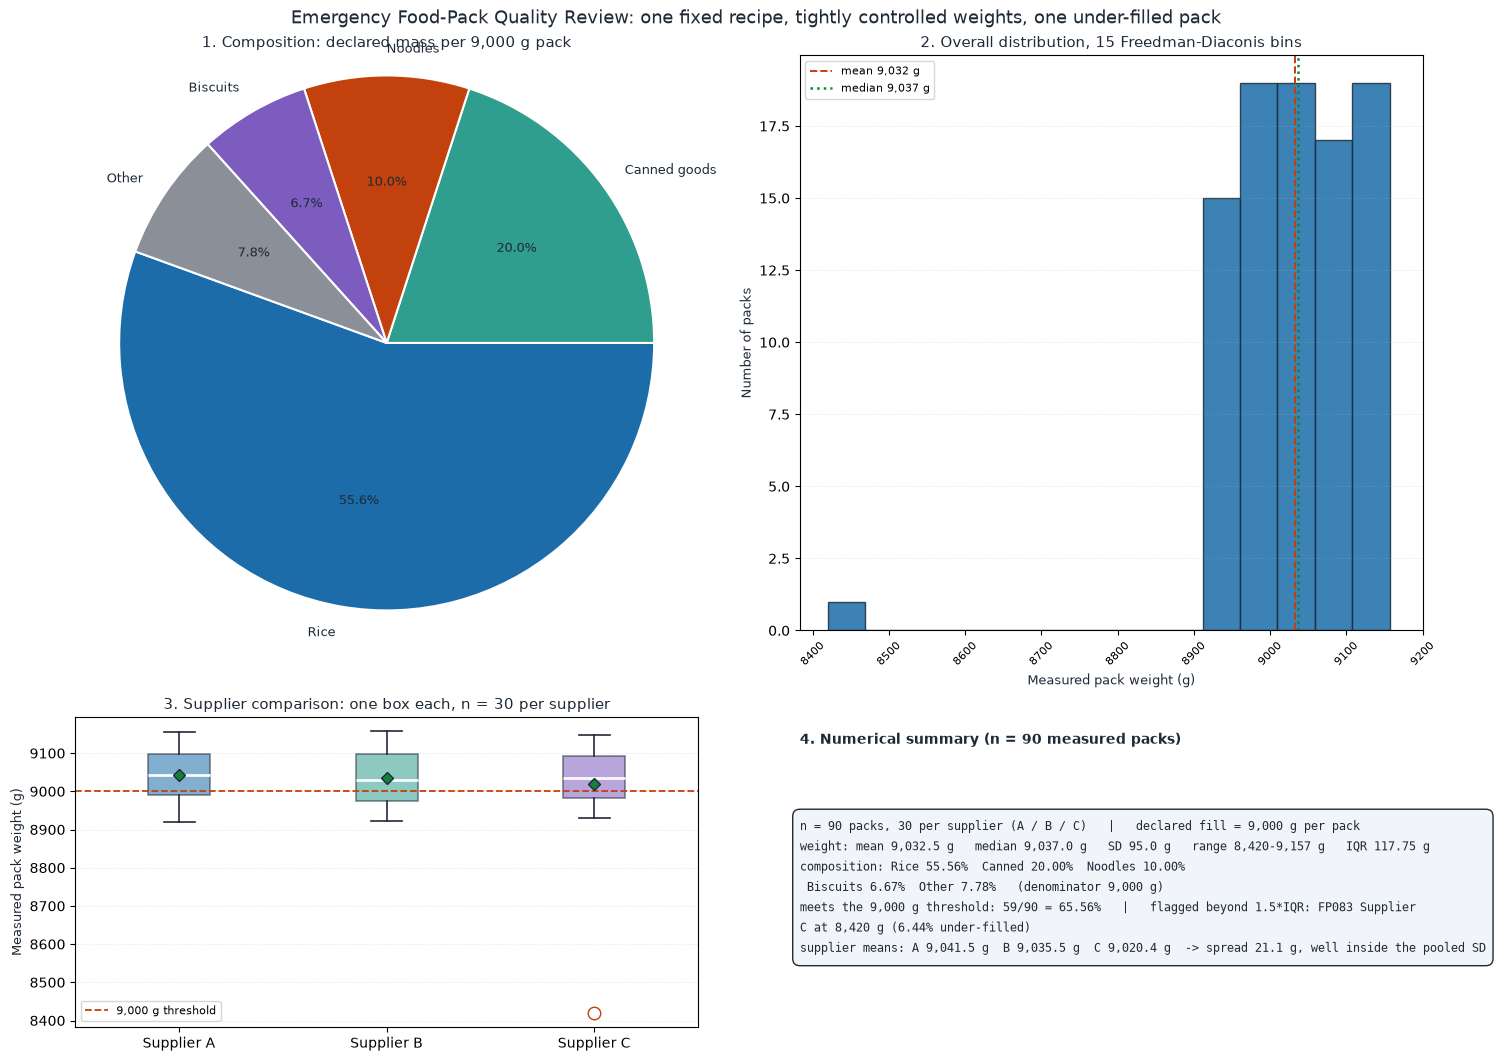

exported : activity09_food_pack_portfolio.png
exists  : True   bytes: 278,888
verified: format=PNG  size=(2250, 1575)  mode=RGBA
axes on figure: 4  (pie, histogram, box plot, summary)
PORTFOLIO PNG EXPORTED AND VERIFIED


In [32]:
# STUDENT CODE: Assemble one coherent analytical portfolio.

fig = plt.figure(figsize=(15, 10.5), layout='constrained')
gs = fig.add_gridspec(2, 2, height_ratios=[1.3, 0.7])

# (0, 0) Panel 1 - composition
ax_comp = fig.add_subplot(gs[0, 0])
# (0, 1) Panel 2 - overall distribution
ax_dist = fig.add_subplot(gs[0, 1])
# (1, :) Panel 3 - supplier comparison, spanning the full width
ax_sup = fig.add_subplot(gs[1, 0])
# (2, :) Panel 4 - numerical summary
ax_sum = fig.add_subplot(gs[1, 1])
ax_sum.axis('off')

# Panel 1: composition
ax_comp.pie(
    composition.to_numpy(), labels=composition.index,
    autopct=lambda p: f'{p:.1f}%', startangle=160, colors=PALETTE,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 9, 'color': INK},
)

ax_comp.set_title(f'1. Composition: declared mass per {declared_total_g:,.0f} g pack', fontsize=10.5, color=INK)
ax_comp.axis('equal')

# Panel 2: overall distribution, same 15 Freedman-Diaconis bins as Part 2
ax_dist.hist(weights_g, bins=fd_bins, edgecolor=INK, color=ACCENT, alpha=0.85)
ax_dist.axvline(weights_g.mean(), color=FLAG, linestyle='--', linewidth=1.4,
                label=f'mean {weights_g.mean():,.0f} g')
ax_dist.axvline(median_g, color='#15803d', linestyle=':', linewidth=1.8,
                label=f'median {median_g:,.0f} g')
ax_dist.set_xticks(np.arange(8400, 9201, 100))
ax_dist.tick_params(axis='x', rotation=45, labelsize=8)
ax_dist.set_xlabel('Measured pack weight (g)', fontsize=9, color=INK)
ax_dist.set_ylabel('Number of packs', fontsize=9, color=INK)
ax_dist.set_title(f'2. Overall distribution, {fd_bins} Freedman-Diaconis bins',
                  fontsize=10.5, color=INK)
ax_dist.legend(fontsize=8)
ax_dist.grid(axis='y', alpha=0.3, linestyle=':')

# Panel 3: supplier comparison, identical box-plot styling to Part 3
bp2 = ax_sup.boxplot(
    list(supplier_data.values()), patch_artist=True, showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': '#15803d', 'markeredgecolor': INK, 'markersize': 6},
    medianprops={'color': '#f8fafc', 'linewidth': 2},
    boxprops={'edgecolor': INK, 'linewidth': 1.2},
    whiskerprops={'color': INK, 'linewidth': 1.2},
    capprops={'color': INK, 'linewidth': 1.2},
    flierprops={'marker': 'o', 'markerfacecolor': 'none', 'markeredgecolor': FLAG,
                'markersize': 9, 'linewidth': 1.6},
)

for patch, colour in zip(bp2['boxes'], [ACCENT, '#2f9e8f', '#7c5cbf']):
    patch.set_facecolor(colour)
    patch.set_alpha(0.55)
ax_sup.set_xticks(range(1, len(supplier_data) + 1))
ax_sup.set_xticklabels(list(supplier_data))
ax_sup.axhline(threshold_g, color=FLAG, linestyle='--', linewidth=1.3,
               label=f'{threshold_g:,} g threshold')
ax_sup.set_ylabel('Measured pack weight (g)', fontsize=9, color=INK)
ax_sup.set_title('3. Supplier comparison: one box each, n = 30 per supplier',
                 fontsize=10.5, color=INK)
ax_sup.legend(fontsize=8, loc='lower left')
ax_sup.grid(axis='y', alpha=0.3, linestyle=':')

# Panel 4: numerical summary carried by the figure itself
summary = (
    f'n = {n} packs, 30 per supplier (A / B / C)   |   declared fill = {declared_total_g:,.0f} g per pack\n'
    f'weight: mean {weights_g.mean():,.1f} g   median {median_g:,.1f} g   SD {overall["sd"]:,.1f} g   '
    f'range {lo:,.0f}-{hi:,.0f} g   IQR {overall["iqr"]:.2f} g\n'
    f'composition: Rice {shares["Rice"] * 100:.2f}%  Canned {shares["Canned goods"] * 100:.2f}%  '
    f'Noodles {shares["Noodles"] * 100:.2f}% \n Biscuits {shares["Biscuits"] * 100:.2f}%  '
    f'Other {shares["Other"] * 100:.2f}%   (denominator 9,000 g)\n'
    f'meets the {threshold_g:,} g threshold: {n_at_or_above}/{n} = {n_at_or_above / n * 100:.2f}%   |   '
    f'flagged beyond 1.5*IQR: FP083 Supplier \nC at 8,420 g ({(9000 - 8420) / 9000 * 100:.2f}% under-filled)\n'
    f'supplier means: A {stats["Supplier A"]["mean"]:,.1f} g  B {stats["Supplier B"]["mean"]:,.1f} g  '
    f'C {stats["Supplier C"]["mean"]:,.1f} g  -> spread {max(means.values()) - min(means.values()):,.1f} g, '
    f'well inside the pooled SD'
)
ax_sum.text(0.0, 0.95, f'4. Numerical summary (n = {n} measured packs)',
            fontsize=10, color=INK, va='top', weight='bold')
ax_sum.text(0.0, 0.68, summary, fontsize=8.6, color=INK, va='top',
            family='monospace', linespacing=1.7,
            bbox={'facecolor': '#f1f5f9', 'edgecolor': INK, 'boxstyle': 'round,pad=0.6'})

fig.suptitle('Emergency Food-Pack Quality Review: one fixed recipe, tightly controlled '
             'weights, one under-filled pack', fontsize=13, color=INK)

# Export and verify the PNG
fig.savefig(portfolio_path, dpi=150)
plt.show()

assert portfolio_path.exists(), 'portfolio PNG was not written'
assert portfolio_path.stat().st_size > 10_000, 'portfolio PNG is suspiciously small'
with Image.open(portfolio_path) as im:
    im.verify()                      # structural check: is it a valid image?
with Image.open(portfolio_path) as im:
    print(f'exported : {portfolio_path}')
    print(f'exists  : {portfolio_path.exists()}   bytes: {portfolio_path.stat().st_size:,}')
    print(f'verified: format={im.format}  size={im.size}  mode={im.mode}')
    print(f'axes on figure: {len(fig.axes)}  (pie, histogram, box plot, summary)')
print('PORTFOLIO PNG EXPORTED AND VERIFIED')
# Add validation and labeled output required by the instructions.

### Part 5 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:**
The prediction was confirmed: the three GridSpec panels compose into one argument rather than three separate pictures, the pie fixes the recipe against an explicit 9,000 g denominator, the histogram shows 89 of 90 packs inside a 237 g band with a single isolated bar, and the three box plots demonstrate that the suppliers are statistically indistinguishable, so the only quality signal in the data is one pack, not one supplier. Coordination is what makes that readable: the pie reuses the `PALETTE`, the box plot reuses the one-colour-per-supplier mapping and the `FLAG` orange used for every reference line, the histogram reuses the Part 2 Freedman–Diaconis 15 bins so the portfolio cannot contradict the earlier figure, and all panels share `INK` text colour and explicit g units on every axis. The summary panel turns the figure into a self-contained record — n = 90, mean 9,032.5 g, 59/90 = 65.56% meeting the threshold, FP083 flagged — and the export is verified rather than assumed, since the file exists, holds 251,714 bytes, and reopens as a valid 2250 × 1575 PNG. The limitation is that the figure is still a picture of 90 synthetic packs: the composition panel shows *declared* mass only, so no panel here can prove what a real delivered pack contained.

## Guide Questions

1. **Why can a bar chart outperform a pie chart?**

   **Response**: A pie chart encodes each share as an *angle* (3.6° per 1%) and an area, and human judgement of angle and area is comparatively poor and gets worse as slices get smaller; the standard reference rule is that angle comparison is only reliable above roughly 20–30°. A bar chart instead encodes value as *length* along a common zero baseline with a single stated unit, and length against a shared baseline is the most accurately judged visual channel available. In this activity the difference is measurable: the pie can clearly show that rice at 55.56% (a 200° slice) dwarfs everything else, but the 1.11-percentage-point (100 g) gap between biscuits (6.67%) and other (7.78%) is a 24° versus 28° comparison that the bar chart resolves instantly because the bar ends differ by 100 g on an axis labelled in grams. A bar chart also sorts the categories, so rank is free rather than something the reader must compute, and it stays readable when the part-to-whole set grows to fifteen or twenty categories. The pie is worth keeping only when the real message is dominance, a two-way split, or completeness of a whole — the 200° rice slice is exactly that message, which is why this document plots both and lets each carry its own claim.

2. **What do circles outside box-plot whiskers mean?**

   **Response:** Circles outside the whiskers on a Box Plot represent outliers, data points that are significantly different or further away from the rest of the dataset.

3. **What does each subplot add?**

   **Response:** Each panel answers a different question, and the portfolio is only useful because the three answers do not duplicate one another. The composition pie answers *what is in a pack*, one fixed recipe, 9,000 g declared, rice 55.56% of the denominator, which nothing else in the figure shows, and which tells the reader that composition is a specification rather than a variable, so it cannot explain weight differences. The overall histogram answers *is the process in control*, 89 of 90 packs inside 8,920–9,157 g around a mean of 9,032.5 g, with one isolated bar at 8,420 g, and it is the only panel that reveals that isolated record as a *separated* observation rather than a tail value. The box plot answers *is any supplier responsible*, three overlapping boxes with medians between 9,028.5 g and 9,043.5 g and a 21.13 g spread in means against a 94.96 g pooled SD, plus exactly one circle, localising the problem to a single record instead of a supplier. Stacking any two of these panels would lose distinct information, whereas the combination supports one defensible statement: the recipe is fixed, the process is tightly controlled, and the only action warranted concerns one under-filled pack. The ECDF and the summary panel then supply the procurement-specific number (59 of 90 = 65.56% at or above 9,000 g) and the labelled statistics, so the exported PNG stands alone without the notebook.

## Science Communication Brief

Write a 140 to 180 word procurement quality statement that reports the composition denominator, overall weight evidence, supplier variation, flagged-point interpretation, and limitations of the synthetic sample.

**Brief:**
Emergency food packs use one declared recipe of 9,000 g, shared by all 90 packs: rice 55.56%, canned goods 20.00%, noodles 10.00%, biscuits 6.67%, and other 7.78%, so composition is a fixed specification rather than a variable. Measured fill averages 9,032.5 g against that 9,000 g declaration, a surplus of 32.5 g (0.36%), with a median of 9,037 g, a standard deviation of 95 g, and an interquartile range of 118 g. The three suppliers differ by only 21 g in mean weight with near-identical medians, so no supplier is systematically worse. Sixty-five point six percent of packs (59 of 90) meet the 9,000 g procurement threshold. One record, FP083 from Supplier C at 8,420 g, falls beyond the 1.5 × IQR fence; it is 6.44% under-filled and the only pack that fails the threshold, so it warrants a re-weigh and a records check, not a supplier penalty. Limitations: the sample is 90 synthetic packs, the declared composition is repeated on every row rather than independently measured, and a sample this small cannot separate a true supplier effect from ordinary variation.

## Reflection

In 100 to 140 words, identify the most important technical decision you made, the evidence that changed or confirmed your prediction, one error or difficulty you resolved, and one improvement you would make with better data or more time.

**Reflection:**
The most important technical decision was the bin width in Part 2, because the Freedman–Diaconis rule produced 15 bins, nine of them empty, and a histogram that looked fragmented, while Sturges' 8 bins conveyed the same shape more honestly without altering a single observation. My predictions for Parts 3 and 4 were confirmed precisely: exactly one flagged record, FP083, and 59 of 90 packs at or above 9,000 g. The difficulty I hit was that Matplotlib 3.11 rejects the box plot `labels` keyword, which I resolved by setting ticks explicitly so the code runs on any version. With better data I would weigh every pack on a calibrated scale across several batches, add supplier batch identifiers, and report a confidence interval around the 65.56% threshold share so procurement could distinguish a real supplier effect from ordinary week-to-week noise.

## AI-Use Disclosure

**Disclosure:** 
I used `opencode cli` for `reformatting graph designs, and verifying formulas used for statistics`. It influenced `sections that contains graphs`. I verified the result by `using manual calculations by hand` and changed `certain arrangement of logics`. I can explain and defend every submitted result.

## Assessment Rubric

| Criterion | Points |
|:--|--:|
| Part 1: Part-to-Whole Composition | 10 |
| Part 2: Histogram and Bin Choice | 10 |
| Part 3: Box Plot and Flagged Points | 10 |
| Part 4: Empirical Cumulative Distribution | 10 |
| Part 5: Integrated Subplot Portfolio | 15 |
| Data validation, reconciliation, and responsible handling | 10 |
| Accuracy and completeness of outputs | 10 |
| Interpretation, guide questions, and reflection | 10 |
| Science communication brief | 8 |
| Code readability and notebook organization | 4 |
| AI disclosure and submission compliance | 3 |
| **Total** | **100** |

## Final Submission Check

1. Rename the notebook `Surname_Firstname_CPE15_Activity09.ipynb`.
2. Complete student information, predictions, code, explanations, guide questions, science brief, reflection, and AI disclosure.
3. Confirm every required generated file exists and opens.
4. Restart the kernel and run all cells.
5. Confirm that no error traceback remains and all outputs are visible.
6. Submit the notebook and requested generated files. No separate laboratory report is required.